# SVD for NLP

## Dependencies

In [17]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.datasets import fetch_20newsgroups
import matplotlib.pyplot as plt

## Step 1: Load a text dataset


In [18]:
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data  # The documents

## Step 2: Create the Document-Term Matrix

In [19]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

## Step 3: Apply SVD for dimensionality reduction of the text

In [20]:
svd = TruncatedSVD(n_components=5, random_state=42)  # Reduce to 50 dimensions
X_svd = svd.fit_transform(X)

## Step 4: Results

In [21]:
print("Original shape of document-term matrix:", X.shape)
print("Shape after SVD:", X_svd.shape)

Original shape of document-term matrix: (18846, 134101)
Shape after SVD: (18846, 5)


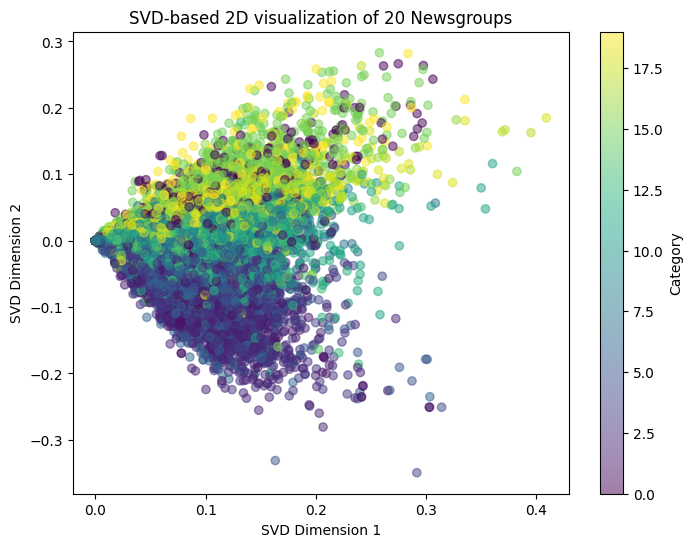

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], alpha=0.5, c=newsgroups.target, cmap='viridis')
plt.colorbar(label='Category')
plt.title('SVD-based 2D visualization of 20 Newsgroups')
plt.xlabel('SVD Dimension 1')
plt.ylabel('SVD Dimension 2')
plt.show()

In [23]:
terms = vectorizer.get_feature_names_out()
for i, topic in enumerate(svd.components_):
    print(f"Top words for topic {i+1}:")
    top_words = [terms[i] for i in topic.argsort()[-10:]]  # Get top 10 words for each topic
    print(" ".join(top_words))
    print()

Top words for topic 1:
time use god does think know people like just don

Top words for topic 2:
christian did bible don say believe think jesus people god

Top words for topic 3:
christian faith dos thanks christ bible does jesus windows god

Top words for topic 4:
controller games drives card hard ide game god scsi drive

Top words for topic 5:
drives controller encryption clipper ide government chip key scsi drive

